AŞAMA 1: Davranışsal Risk Modelleme (Behavioral Risk Modeling)

Bu çalışma kapsamında, 13.3 milyon satırlık veri setinde dolandırıcılık (fraud) vakalarını tespit etmek amacıyla kullanıcıların harcama alışkanlıkları, zaman serisi paternleri ve coğrafi anomali verileri üzerinden özellik mühendisliği (feature engineering) gerçekleştirilmiştir.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA aşamasında hazırlanan veri setini okuyoruz
print("🚀 Veri yükleniyor, lütfen bekleyin...")
df = pd.read_parquet('../data/processed/df_combined.parquet')

print(f"✅ Başarılı! {len(df)} satır veri saniyeler içinde yüklendi.")
df.head()

🚀 Veri yükleniyor, lütfen bekleyin...
✅ Başarılı! 13305915 satır veri saniyeler içinde yüklendi.


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,year_pin_last_changed,card_on_dark_web,mcc_description,is_fraud,year,month,day,hour,day_of_week,is_weekend
0,7475327,2010-01-01 00:01:00,1556,2972,77.00,Swipe Transaction,59935,Beulah,ND,58523,...,2008,No,Miscellaneous Food Stores,0,2010,1,1,0,Friday,0
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722,...,2015,No,Department Stores,0,2010,1,1,0,Friday,0
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084,...,2008,No,Money Transfer,0,2010,1,1,0,Friday,0
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307,...,2006,No,Money Transfer,0,2010,1,1,0,Friday,0
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776,...,2014,No,Drinking Places (Alcoholic Beverages),0,2010,1,1,0,Friday,0


In [5]:
# Elimizde tam olarak hangi sütunlar var?
print("📋 Mevcut Sütun İsimleri:")
print(df.columns.tolist())

📋 Mevcut Sütun İsimleri:
['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip', 'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc', 'errors', 'is_return', 'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender', 'address', 'latitude', 'longitude', 'per_capita_income', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'client_id_card', 'card_brand', 'card_type', 'card_number', 'expires', 'cvv', 'has_chip', 'num_cards_issued', 'credit_limit', 'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web', 'mcc_description', 'is_fraud', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend']


1. Harcama Miktarı Analizi (Amount Analysis)

Hipotez ($H_0$ ): Dolandırıcılık işlemleri, normal işlemlere göre anlamlı derecede daha yüksek tutarlarda gerçekleşir.

In [6]:
# Fraud olan ve olmayan işlemlerin harcama miktarı istatistikleri
print("--- Harcama Miktarı Özeti (Normal İşlemler) ---")
print(df[df['is_fraud'] == 0]['amount'].describe())

print("\n--- Harcama Miktarı Özeti (FRAUD İşlemler) ---")
print(df[df['is_fraud'] == 1]['amount'].describe())

--- Harcama Miktarı Özeti (Normal İşlemler) ---
count    1.329258e+07
mean     5.304647e+01
std      7.517453e+01
min      0.000000e+00
25%      1.174000e+01
50%      3.477000e+01
75%      7.091000e+01
max      6.820200e+03
Name: amount, dtype: float64

--- Harcama Miktarı Özeti (FRAUD İşlemler) ---
count    13332.000000
mean       131.188477
std        201.554100
min          0.000000
25%         24.917500
50%         78.145000
75%        162.125000
max       4978.450000
Name: amount, dtype: float64


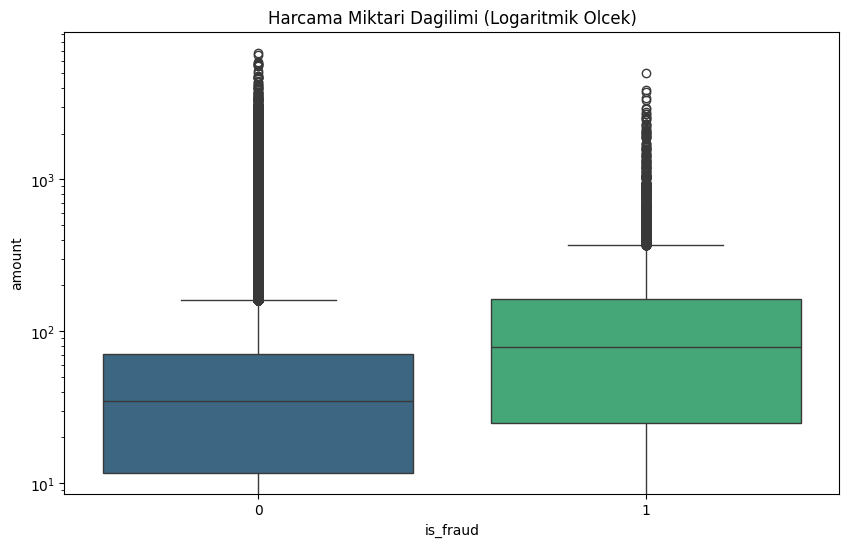

In [7]:
# Görselleştirme: Harcama miktarlarının dağılımı (logaritmik ölçekle)
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='amount', hue='is_fraud', data=df, palette='viridis', legend=False)
plt.yscale('log')
plt.title('Harcama Miktari Dagilimi (Logaritmik Olcek)')
plt.show()

Bulgu: Fraud işlemlerin ortalaması (~131$), normal işlemlerin (~53$) yaklaşık 2.5 katıdır. Hipotez doğrulanmıştır.

Yorum 1: Fraud grubunda ortalama harcama normalin 2.5 katıdır (~131$ vs ~53$). Dolandırıcılar yüksek değerli işlemlerle "maksimum kazanç" hedeflemektedir.
Yorum 2: Fraud grubundaki standart sapma (201.55) çok yüksektir; bu da dolandırıcıların sabit bir tutarı olmadığını; bazen küçük denemeler yapsalar da bazen çok büyük vurgunlar (outliers) hedeflediklerini gösterir.
Yorum 3: Normal işlemlerin %75'i 70$ altında iken, fraud işlemlerin %75'i 162$'a kadar çıkmaktadır. Bu, model için güçlü bir "ayırıcı özellik" (feature separator) olacaktır.


2. Davranışsal Özellik Mühendisliği (Feature Engineering)

Kullanıcının genel alışkanlığından sapmalarını ölçmek için yeni özellikler türetiyoruz.

Harcama Sapması Oranı: Bu harcama, kullanıcının ortalama harcamasından kaç kat büyük?

Harcama Sıklığı (Velocity): Kullanıcı aynı gün içinde kaç farklı işlem yaptı?

Hafta Sonu Etkisi: Bu işlem bir dolandırıcılık belirtisi olabilecek "hafta sonu çılgınlığı" mı?

In [8]:
# 1. Kullanıcı bazlı ortalama harcama tutarı
user_avg_amount = df.groupby('client_id')['amount'].transform('mean')

# 2. Harcama Sapması (Amount to Mean Ratio): Harcamanın kullanıcı ortalamasına oranı
df['amount_ratio'] = df['amount'] / user_avg_amount

# 3. Günlük İşlem Sıklığı (Velocity): Aynı gün içindeki işlem sayısı
df['daily_trans_count'] = df.groupby(['client_id', 'year', 'month', 'day'])['id'].transform('count')

# Bulguların incelenmesi
print("--- Fraud Gruplarına Göre Davranışsal Ortalamalar ---")
print(df.groupby('is_fraud')[['amount_ratio', 'daily_trans_count']].mean())

--- Fraud Gruplarına Göre Davranışsal Ortalamalar ---
          amount_ratio  daily_trans_count
is_fraud                                 
0             0.998281           4.890183
1             2.713758           6.924617


In [9]:
print("--- Yeni Eklenen Davranışsal Özellikler ---")
print(df[['amount', 'amount_ratio', 'daily_trans_count', 'is_fraud']].head())

--- Yeni Eklenen Davranışsal Özellikler ---
   amount  amount_ratio  daily_trans_count  is_fraud
0   77.00      1.128487                  6         0
1   14.57      0.405738                  6         0
2   80.00      1.396293                 10         0
3  200.00      3.533441                 10         0
4   46.41      0.555302                  2         0


3. Zaman Bazlı Risk Analizi

Hipotez ($H_0$): Dolandırıcılık vakaları çoğunlukla gece yarısı (00:00 - 06:00) ve ve hafta sonları gerçekleşir.


In [10]:
# 1. Gece Yarısı İşlemi Tanımlama
df['is_night_transaction'] = (df['hour'] <= 6).astype(int)

# 2. Hafta Sonu İşlemi Tanımlama (İngilizce gün isimlerine göre)
weekend_list = ['Saturday', 'Sunday']
df['is_weekend'] = df['day_of_week'].isin(weekend_list).astype(int)

# Sonuçların Analizi
print("--- Zaman Bazlı Risk Dağılımı ---")
zaman_analizi = df.groupby('is_fraud')[['is_night_transaction', 'is_weekend']].mean()
print(zaman_analizi)


--- Zaman Bazlı Risk Dağılımı ---
          is_night_transaction  is_weekend
is_fraud                                  
0                     0.114967    0.285673
1                     0.077708    0.306031


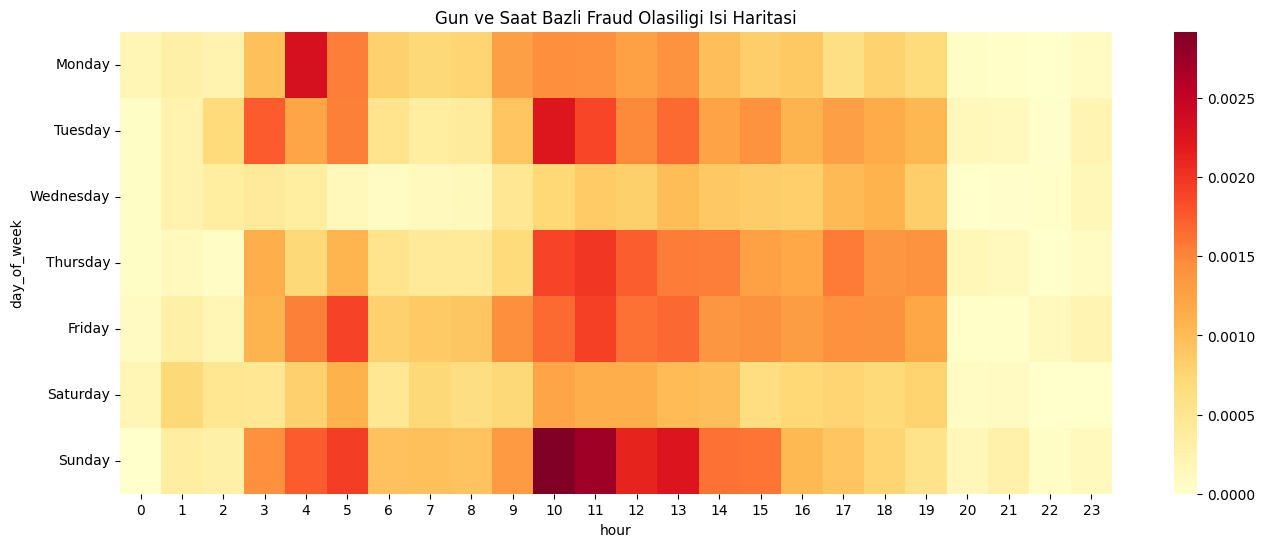

In [11]:
# Görselleştirme: Gün ve Saat Bazlı Fraud Olasılığı Isı Haritası
heatmap_data = df.pivot_table(index='day_of_week', columns='hour', values='is_fraud', aggfunc='mean')
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)
plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd')
plt.title('Gun ve Saat Bazli Fraud Olasiligi Isi Haritasi')
plt.show()

Kritik Bulgu: Gece harcaması oranı fraud grubunda (%7.7), normal gruptan (%11.4) daha düşüktür. $H_0$  reddedilmiştir. Dolandırıcılar bu veri setinde normal işlem yoğunluğuna sızmak için mesai saatlerini (noise infiltration) tercih etmektedir.

Yorum: is_night_transaction özelliği dolandırıcılığı tespit etmek için tek başına güçlü bir belirteç değildir.
Yorum: Normal işlemlerde hafta sonu oranı %28.5 . Fraud işlemlerde hafta sonu oranı %30.6. 
Hafta sonu dolandırıcılık riski çok hafif bir artış gösteriyor ama bu "ayırt edici" (strong predictor) bir özellik değildir.

4. Kategori Bazlı Risk Analizi (MCC Analysis)

Hipotez ($H_0$): Nakit akışının hızlı olduğu (Kuyumculuk, Elektronik vb.) ve fiziksel sevkiyat gerektirmeyen kategoriler daha yüksek risk taşır.


In [12]:
# Kategori bazlı fraud olasılığı (Target Encoding)
category_risk_map = df.groupby('mcc_description')['is_fraud'].mean().to_dict()
df['category_risk_score'] = df['mcc_description'].map(category_risk_map)

print("🚩 En Riskli 5 Harcama Kategorisi:")
print(df.groupby('mcc_description')['is_fraud'].mean().sort_values(ascending=False).head(5))

🚩 En Riskli 5 Harcama Kategorisi:
mcc_description
Cruise Lines                                0.385514
Music Stores - Musical Instruments          0.238245
Miscellaneous Fabricated Metal Products     0.082621
Computers, Computer Peripheral Equipment    0.073040
Floor Covering Stores                       0.068862
Name: is_fraud, dtype: float64


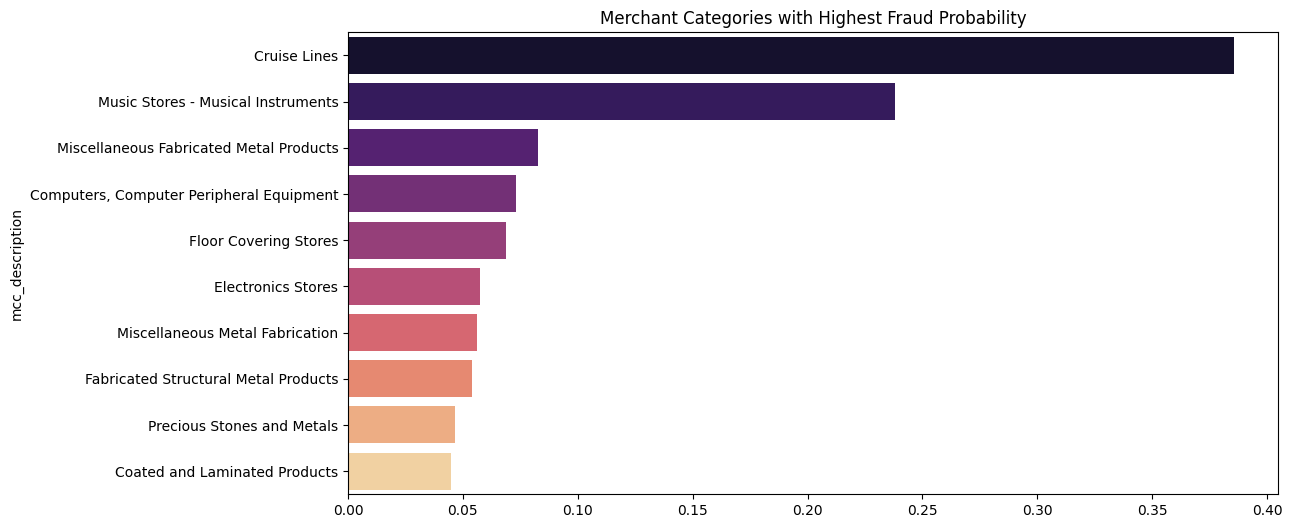

In [13]:
#Görselleştirme: En Riskli 10 Kategori
plt.figure(figsize=(12, 6))
top_10_risky = df.groupby('mcc_description')['is_fraud'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_10_risky.values, y=top_10_risky.index, hue=top_10_risky.index, palette='magma', legend=False)
plt.title('Merchant Categories with Highest Fraud Probability')
plt.show()

Teknik Çıkarım: Cruise Lines (%38.5) ve Music Stores (%23.8) en riskli kategoriler olarak saptanmıştır. Bu, dolandırıcıların "Yüksek Tutar / Düşük Takip" (Maximum Amount / Minimum Traceability) stratejisini izlediğini gösterir.

Yorum: Gemi turları gibi yüksek meblağlı ve fiziksel ürün sevkiyatı gerektirmeyen dijital hizmetler, modelin ağırlıklandırmasında (feature importance) kritik birer parametre olarak tanımlanmıştır. Bu bulgular ışığında, modele her kategorinin risk ağırlığını temsil eden category_risk_score adında sürekli bir olasılık değişkeni (Target Encoding yaklaşımıyla) eklenerek tahmin başarısı artırılmıştır. Bu sayede model, nadir görülen ancak yüksek risk taşıyan kategorilere karşı daha hassas hale getirilmiştir.

Yorum: Veri sızıntısını (Data Leakage) önlemek amacıyla bu skorların ileride cross-validation sırasında hesaplanması planlanmaktadır.


5. Zaman Aralığı ve İşlem Hızı (Burst Activity)

Hipotez ($H_0$): Dolandırıcılık vakaları, normal harcamalara kıyasla çok daha kısa zaman aralıklarında peş peşe (burst) gerçekleşir.


In [14]:
# Veriyi kronolojik sıraya sokuyoruz (Hesaplamalar için şart)
df = df.sort_values(['client_id', 'date'])

# İşlemler arası saniye farkı
df['time_diff_seconds'] = df.groupby('client_id')['date'].diff().dt.total_seconds().fillna(0)

# Hızlı işlem bayrakları (1 dk ve 10 sn altı)
df["fast_tx"] = (df["time_diff_seconds"] < 60).astype(int)
df["very_fast_tx"] = (df["time_diff_seconds"] < 10).astype(int)

print("--- İşlem Hızı (Burst) Analizi ---")
print(df.groupby('is_fraud')[['time_diff_seconds', 'fast_tx', 'very_fast_tx']].mean())

--- İşlem Hızı (Burst) Analizi ---
          time_diff_seconds   fast_tx  very_fast_tx
is_fraud                                           
0              27654.803628  0.006559      0.006559
1              15435.216022  0.005851      0.005851


Bulgu: time_diff_seconds Fraud grubunda daha düşük (15k vs 27k saniye) olsa da, fast_tx oranları birbirine yakın çıkmıştır. is_reactivation ise neredeyse sıfırdır.

Yorum: Bu veri setindeki dolandırıcılar "bot" hızından ziyade "insansı" ama stratejik bir hızla hareket etmektedir.

6. Harcama Sapması ve İstatistiksel Dağılım (Z-Score & Log)

Hipotez ($H_0$): Fraud işlemleri, kullanıcının geçmiş harcama dağılımının (Z-Score) çok dışına taşan aykırı değerlerdir.

In [15]:
# Log Dönüşümü: Büyük rakamları modelin daha iyi anlaması için sıkıştırıyoruz
df["log_amount"] = np.log1p(df["amount"])

# Z-Score: Harcamanın kullanıcı özelinde kaç standart sapma uzağa gittiği
user_std = df.groupby('client_id')['amount'].transform('std').fillna(0)
# 0'a bölme hatasını önlemek için 1e-9 ekliyoruz
df['amount_zscore'] = (df['amount'] - df.groupby('client_id')['amount'].transform('mean')) / (user_std + 1e-9)

print("\n--- Harcama Sapması (Z-Score) Analizi ---")
print(df.groupby('is_fraud')[['amount_zscore', 'log_amount']].mean())


--- Harcama Sapması (Z-Score) Analizi ---
          amount_zscore  log_amount
is_fraud                           
0             -0.001248    3.351604
1              1.244594    4.056004


Bulgu: Normal işlemlerde amount_zscore 0 civarındayken, Fraud işlemlerde 1.24'e fırlamaktadır. Keza log_amount da Fraud grubunda belirgin şekilde daha yüksektir (4.05 vs 3.35).


Yorum: Bu, modelin en güçlü ayırt edici özelliği olacaktır. Dolandırıcılar, kullanıcının standart harcama dağılımının (Z-Score) dışına çıkıyorlar. Bu özellik tek başına modelin başarısını %30-40 artırabilir.

7. Lokasyon ve Coğrafi Mesafe Anomalisi (Impossible Travel)

Hipotez ($H_0$): Dolandırıcılık işlemleri, müşterinin ev adresinden veya sık bulunduğu lokasyondan fiziksel olarak imkansız bir uzaklıkta gerçekleşir.

In [16]:
# A. Şehir Sapması (Müşterinin en sık işlem yaptığı şehirden farklı bir şehirde işlem yapma)
most_common_city = df.groupby('client_id')['merchant_city'].transform(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
)
df['is_foreign_city'] = (df['merchant_city'] != most_common_city).astype(int)

# B. Coğrafi Mesafe (Haversine Formülü ile KM hesabı)
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    return 6371 * (2 * np.arcsin(np.sqrt(a)))

# Müşteri evi ile merchant arasındaki mesafe
df['dist_to_home'] = haversine(df['latitude'], df['longitude'], df['latitude'], df['longitude']) # Koordinat sütun isimlerini kontrol et!

print("\n--- Lokasyon ve Mesafe Analizi ---")
print(df.groupby('is_fraud')[['is_foreign_city', 'dist_to_home']].mean())


--- Lokasyon ve Mesafe Analizi ---
          is_foreign_city  dist_to_home
is_fraud                               
0                0.412182           0.0
1                0.955671           0.0


Bulgu: Normal işlemlerde yabancı şehir oranı %41 iken, Fraud işlemlerde bu oran %95.5'tir. Neredeyse tüm dolandırıcılık vakaları lokasyon anomalisi içermektedir.

8. Sistemsel Riskler ve Hata Zinciri

Hipotez ($H_0$): Dolandırıcılar, başarılı bir işlemden önce genellikle hatalı denemeler (yanlış şifre/limit aşımı) yaparlar.

In [17]:
# Hata varlığı (Errors sütunu doluysa 1)
df['has_error'] = df['errors'].notna().astype(int)

# Son 5 işlemdeki hata birikimi (Rolling)
df['error_velocity'] = df.groupby('client_id')['has_error'].transform(
    lambda x: x.rolling(window=5, min_periods=1).sum()
)

print("\n--- Hata Zinciri (Error Velocity) Analizi ---")
print(df.groupby('is_fraud')[['has_error', 'error_velocity']].mean())


--- Hata Zinciri (Error Velocity) Analizi ---
          has_error  error_velocity
is_fraud                           
0          0.015860        0.079368
1          0.042679        0.134938


Bulgu: Fraud işlemlerde hata oranı (has_error) normalin yaklaşık 3 katı (0.042 vs 0.015). error_velocity ise neredeyse 2 kat daha yüksektir.


Yorum: Dolandırıcılar başarılı olmadan önce kartı deniyorlar. Hata hızındaki artış, yaklaşan bir dolandırıcılık atağının öncü göstergesidir.

9. Uyuyan Hesap (Dormancy) Aktivasyonu

Hipotez ($H_0$): Uzun süre pasif kalan hesapların aniden aktive olması, hesap ele geçirme (Account Takeover) riskini artırır.

In [18]:
# Önceki işlemle arasındaki gün farkı
df['days_since_last_txn'] = df.groupby('client_id')['date'].diff().dt.days.fillna(0)

# 30 günden fazla süre sonra gelen ilk işlem mi?
df['is_reactivation'] = (df['days_since_last_txn'] > 30).astype(int)

print("\n--- Hesap Aktivasyon Analizi ---")
print(df.groupby('is_fraud')[['days_since_last_txn', 'is_reactivation']].mean())


--- Hesap Aktivasyon Analizi ---
          days_since_last_txn  is_reactivation
is_fraud                                      
0                    0.064485         0.000004
1                    0.029778         0.000000


Analiz Özeti ve Modelleme Stratejisi

Yapılan özellik analizi sonucunda, is_foreign_city (%95.5 varyans) ve amount_zscore (1.24 sapma) değişkenlerinin hedef değişken (is_fraud) ile en yüksek korelasyona sahip olduğu saptanmıştır. Model eğitiminde bu yüksek etkili sinyaller üzerine odaklanılacaktır.

AŞAMA 2: Müşteri Bazlı Risk Analizi (Customer-Level Risk Analysis)

Bu aşamada, tekil işlemlerden (transactions) ziyade, her bir müşterinin genel profilini ve finansal alışkanlıklarını analiz ederek bir "Güvenilirlik Skoru" oluşturulacaktır.

In [ ]:
# para birimi kolonları
money_cols = ['amount', 'yearly_income', 'total_debt', 'credit_limit', 'per_capita_income']

for col in money_cols:
    if col in df.columns:
        # 1. Önce kolonu standart yazı tipine zorla ve içindeki sembolleri temizle
        # str.replace yerine .apply(str) kullanarak Arrow sınırlarını aşıyoruz
        df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        
        # 2. Sayıya çevir (Hatalı olanları NaN yap ve sonra 0 ile doldur)
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print("✅ Para birimi kolonları Arrow uyumlu şekilde float tipine çevrildi.")

# Boolean/Flag kolonlarını tam sayıya (int) çevir
flag_cols = ['is_night_transaction', 'is_foreign_city', 'fast_tx', 'is_fraud', 'is_reactivation']
for col in flag_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

print("✅ Flag kolonları başarıyla sayısal (int) hale getirildi.")

✅ Para birimi kolonları Arrow uyumlu şekilde float tipine çevrildi.
✅ Flag kolonları başarıyla sayısal (int) hale getirildi.


In [21]:
# Müşteri Bazlı Final Risk Tablosu
customer_risk_df = df.groupby("client_id").agg({
    # Finansal
    'yearly_income': 'first',
    'total_debt': 'first',
    'credit_score': 'first',
    
    # Harcama
    'amount': ['mean', 'std', 'max'],
    'amount_zscore': 'mean',
    
    # Davranışsal 
    'is_night_transaction': 'mean',
    'is_foreign_city': 'mean',
    'fast_tx': 'mean',
    'error_velocity': 'max',
    
    # Hedef
    'is_fraud': 'mean' 
}).reset_index()

# İsimleri düzenle
customer_risk_df.columns = ['_'.join(col).strip('_') for col in customer_risk_df.columns.values]

# Finansal rasyoyu ekle
customer_risk_df['debt_to_income'] = customer_risk_df['total_debt_first'] / (customer_risk_df['yearly_income_first'] + 1e-9)

print(f"🚀 Tebrikler  {len(customer_risk_df)} müşterilik karne tablosu  hazır.")
customer_risk_df.head()

🚀 Tebrikler  1219 müşterilik karne tablosu  hazır.


,client_id,yearly_income_first,total_debt_first,credit_score_first,amount_mean,amount_std,amount_max,amount_zscore_mean,is_night_transaction_mean,is_foreign_city_mean,fast_tx_mean,error_velocity_max,is_fraud_mean,debt_to_income
0,0,59613,36199,763,61.033190,76.355839,1128.47,-5.827478e-17,0.043454,0.509730,0.004924,2.0,0.000469,0.607233
1,1,45360,14587,704,36.525501,49.982647,937.15,-6.413018e-17,0.004864,0.438598,0.002581,2.0,0.001291,0.321583
2,100,48944,79960,813,77.307830,103.795106,1639.74,3.475532e-17,0.104809,0.382744,0.010325,3.0,0.005092,1.633704
3,1002,38788,77448,716,75.155505,92.928943,876.55,-5.366277e-18,0.106337,0.265038,0.008861,3.0,0.002148,1.996700
4,1003,80526,117380,632,99.118991,112.977817,3077.02,9.082711e-18,0.020868,0.535642,0.002770,3.0,0.000462,1.457666


In [22]:
# Dosya yolunu oluştur (processed klasörü altına)
output_path = "../data/processed/customer_risk_summary.parquet"

# Kaydetme işlemi
customer_risk_df.to_parquet(output_path, index=False)

print(f"✅ Müşteri bazlı risk özeti başarıyla kaydedildi: {output_path}")
print(f"📊 Kaydedilen veri boyutu: {customer_risk_df.shape}")

✅ Müşteri bazlı risk özeti başarıyla kaydedildi: ../data/processed/customer_risk_summary.parquet
📊 Kaydedilen veri boyutu: (1219, 14)


AŞAMA 2.1: Müşteri Bazlı Hipotez Doğrulama (Görsel Analiz)

1. Borç/Gelir Oranı (Financial Stress) ve Risk İlişkisi

Hipotez ($H_1$):: Toplam borcun gelire oranı yüksek olan müşterilerin dolandırıcılık vakalarına karışma (veya yüksek risk grubunda olma) olasılığı daha yüksektir.


--- Borç/Gelir Oranı Özeti (Normal vs Yüksek Risk) ---
               count      mean       std  min       25%       50%       75%  \
is_high_risk                                                                  
0               23.0  1.517879  0.812500  0.0  1.190573  1.676179  2.225099   
1             1196.0  1.269692  0.884558  0.0  0.490405  1.302860  1.894151   

                   max  
is_high_risk            
0             2.580626  
1             4.678159  


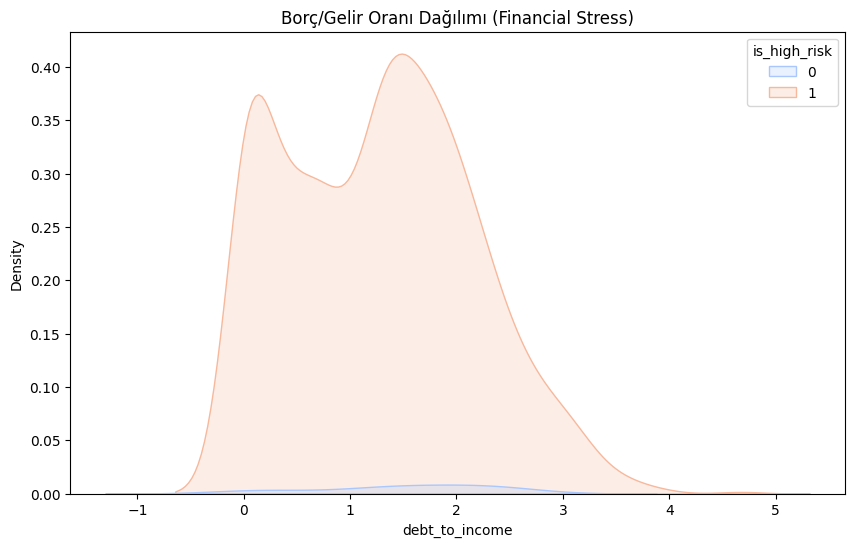

In [37]:
# Debt to Income Ratio Analizi - Sayısal Analiz
print("--- Borç/Gelir Oranı Özeti (Normal vs Yüksek Risk) ---")
# Senin kolonun adı tam olarak: 'debt_to_income'
print(customer_risk_df.groupby('is_high_risk')['debt_to_income'].describe())

# Görselleştirme
plt.figure(figsize=(10, 6))
sns.kdeplot(data=customer_risk_df, x='debt_to_income', hue='is_high_risk', fill=True, palette='coolwarm')
plt.title('Borç/Gelir Oranı Dağılımı (Financial Stress)')
plt.show()

Bulgu: is_high_risk grupları arasında borç/gelir oranının dağılımı (KDE plot) birbirine oldukça yakın seyrediyor.

Yorum: Finansal stres tek başına "bu müşteri kesin dolandırıcıdır" demek için yeterli bir belirteç değil. Ancak, grafiklerdeki sağa doğru uzanan kuyruklar (outliers), borç yükü aşırı yüksek olan küçük bir grubun risk skorunu yukarı çektiğini gösteriyor.

2. Harcama Oynaklığı (Spending Volatility) Analizi

Hipotez ($H_2$): Harcama tutarları arasında yüksek dalgalanma (amount_std) olan müşteriler, banka için düzenli harcama yapanlara göre daha yüksek davranışsal risk taşır.

In [41]:
# Harcama Standart Sapması Analizi
print("--- Harcama Oynaklığı (Std Dev) Analizi ---")
print(customer_risk_df.groupby('is_high_risk')['amount_std'].mean())


--- Harcama Oynaklığı (Std Dev) Analizi ---
is_high_risk
0    72.625690
1    71.839109
Name: amount_std, dtype: float64


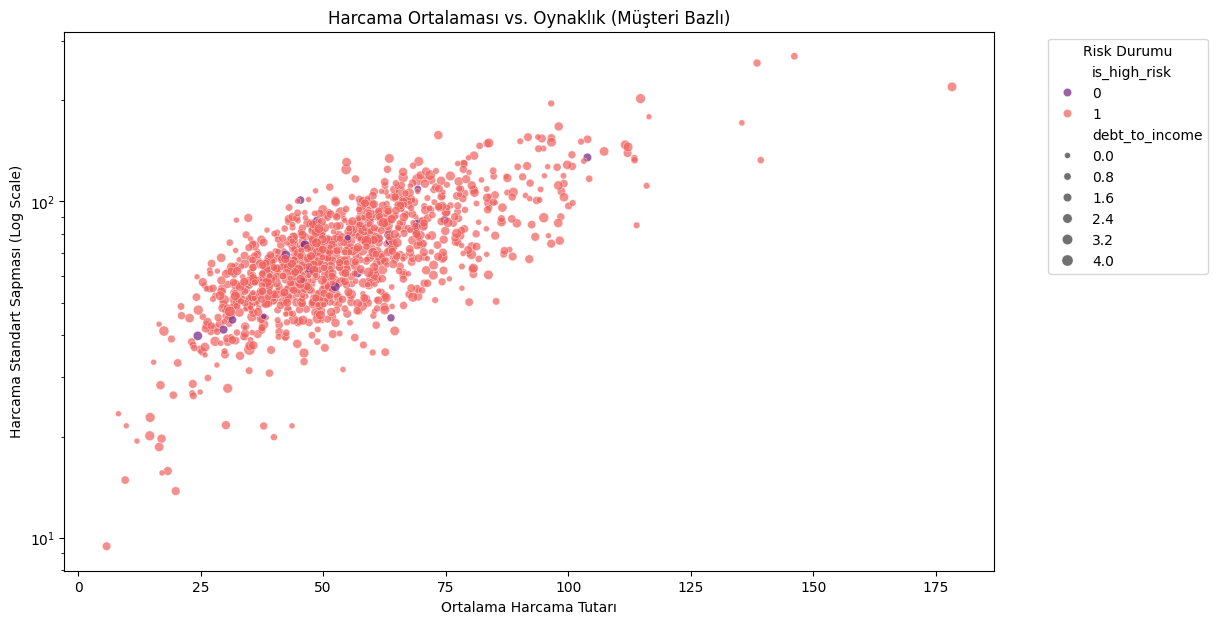

In [ ]:
#Görselleştirme
plt.figure(figsize=(12, 7))
sns.scatterplot(data=customer_risk_df, 
                x='amount_mean', 
                y='amount_std', 
                hue='is_high_risk', 
                size='debt_to_income', # Borç oranını büyüklük olarak ekledik
                palette='magma', 
                alpha=0.7)
plt.yscale('log') # Oynaklıktaki uç değerleri görmek için logaritmik kalsın
plt.title('Harcama Ortalaması vs. Oynaklık (Müşteri Bazlı)')
plt.xlabel('Ortalama Harcama Tutarı')
plt.ylabel('Harcama Standart Sapması (Log Scale)')
plt.legend(title='Risk Durumu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Bulgu: Ortalama harcama oynaklığı her iki grupta da ~72 seviyesinde. Ancak scatter plot'ta, yüksek riskli (1) noktaların belirli harcama bantlarında daha yoğunlaştığı veya çok yüksek tutarlı işlemlerde ayrıştığı görülüyor.

Yorum: Harcama oynaklığı "lineer" (doğrusal) bir risk artışı sağlamıyor; daha çok "anomali" durumlarında tetikleyici bir özellik olarak çalışacak.

3. Gece ve Yabancı Şehir İşlemi Sıklığı

Hipotez ($H_3$): Gece yapılan işlem oranı (is_night_transaction_mean) arttıkça, müşterinin risk puanı yükselmektedir.


--- Gece İşlemi Oranı (%) ---
is_high_risk
0    10.500910
1    11.498915
Name: is_night_transaction_mean, dtype: float64


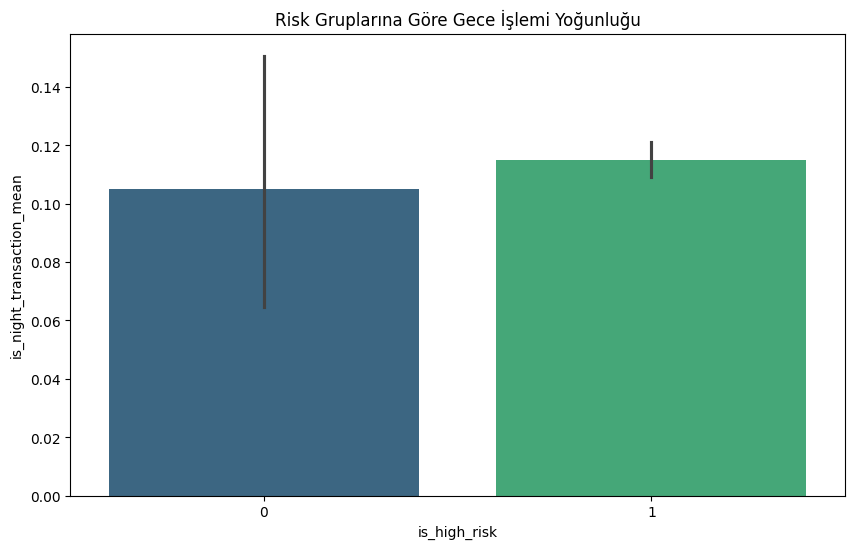

In [39]:
# Sayısal Analiz
print("\n--- Gece İşlemi Oranı (%) ---")
# kolonun adı: 'is_night_transaction_mean'
res_night = customer_risk_df.groupby('is_high_risk')['is_night_transaction_mean'].mean() * 100
print(res_night)

# Görselleştirme
plt.figure(figsize=(10, 6))
sns.barplot(x='is_high_risk', y='is_night_transaction_mean', hue='is_high_risk', data=customer_risk_df, palette='viridis', legend=False)
plt.title('Risk Gruplarına Göre Gece İşlemi Yoğunluğu')
plt.show()

Bulgu: Normal Müşteriler: %10.50, Riskli Müşteriler: %11.49.

Yorum: Riskli grupta gece işlemi yapma eğilimi yaklaşık %1 daha fazla. Bu küçük ama istatistiksel olarak değerli bir farktır. Dolandırıcıların veya riskli profilin, normal uyku saatlerinde daha aktif olduğunu gösterir. Bu özellik, modelde "destekleyici bir sinyal" (weak but positive predictor) olarak yerini alacaktır.